# Fitting Conductivity with Streched Exponentials

Author: [Rylan Stutters](https://github.com/RylanDS7)

Notebook to fit the cole-cole conductivity model to stretched exponential functions under a step down response

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from simpeg import *
import numpy as np
import matplotlib.pyplot as plt
from discretize import TensorMesh
from EMIP import SEInv

In [2]:
# cole cole function
def ColeColeSeigel(f, sigmaInf, eta, tau, c):
    w = 2*np.pi*f
    return sigmaInf*(1 - eta/(1 + (1j*w*tau)**c))

In [3]:
# CC SE function for step off
def ColeSEImpulsefun(eta, tau, c, time):
    return eta*c/time*((time/tau)**c)*np.exp(-(time/tau)**c)

In [4]:
# obtain predicted behavior via Hankel Transform with cos filters
# TODO Review/update
def predictSE(sigmaInf, eta, tau, c):
    from utils import DigFilter # module to be deprecated

    t = np.logspace(-6,np.log10(0.01), 41)
    wt, tbase, omega_int = DigFilter.setFrequency(t)
    f = omega_int / (2*np.pi)

    CC = ColeColeSeigel(f, sigmaInf, eta, tau, c)
    sigTCole = -DigFilter.transFiltImpulse(CC, wt, tbase, omega_int, t, tol=1e-12) # not sure why this has to be negative

    return sigTCole, t


In [50]:
# fit SE parameters with SimPEG inversion
def fitSEparam(obsData, mCC0, t):
    dtrue = obsData
    survey = SEInv.SESurvey(t)
    sim = SEInv.SEInvProblem(survey=survey)

    relative_error = 0.01   # 5%
    noise_floor = 1e-8      # small absolute floor
    std = relative_error * np.abs(dtrue) + noise_floor

    data_obj = data.Data(survey=survey, dobs=dtrue, standard_deviation=std)

    misfit = data_misfit.L2DataMisfit(data=data_obj, simulation=sim)
    mesh = TensorMesh([3])
    reg = regularization.Smallness(mesh)
    opt = optimization.InexactGaussNewton(maxIter=10)

    inv_prob = inverse_problem.BaseInvProblem(misfit, reg, opt)
    inv = inversion.BaseInversion(inv_prob)

    mrec = inv.run(mCC0)

    print("Recovered model:", mrec)

    return mrec

In [51]:
eta1, tau1, c1 = 0.1, 1e-3, 0.5
mCC = np.array([eta1, tau1, c1])

obsSigma, t = predictSE(1, eta1, tau1, c1)

mSE = fitSEparam(obsSigma, mCC, t)
predSigma = ColeSEImpulsefun(mSE[0], mSE[1], mSE[2], t)

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
[0.1   0.001 0.5  ]
   0  1.00e+00  1.41e+04  0.00e+00  1.41e+04                                 
[0.09999362 0.000922   0.49999852]
   1  1.00e+00  1.36e+04  2.04e-09  1.36e+04    1.27e+07      0              
[0.08837129 0.00092762 0.44300353]
   2  1.00e+00  1.26e+03  1.13e-03  1.26e+03    1.92e+06      0   Skip BFGS  
[0.08908229 0.00094079 0.44287453]
   3  1.00e+00  1.24e+03  1.13e-03  1.24e+03    5.60e+05      0              
[0.08912609 0.00095222 0.43871614]
   4  1.00e+00  1.21e+03  1.29e-03  1.21e+03    4.73e+04      0              
[0.08912405 0.00095332 0.43871651]
   5  1.00e+00  1.21e+03  1.29e-03  1.21e+03    1.24e+05      0              
[0.08914456 0.00095341 0.43879385]
   6  1.00e+00  1.21e+03  1.

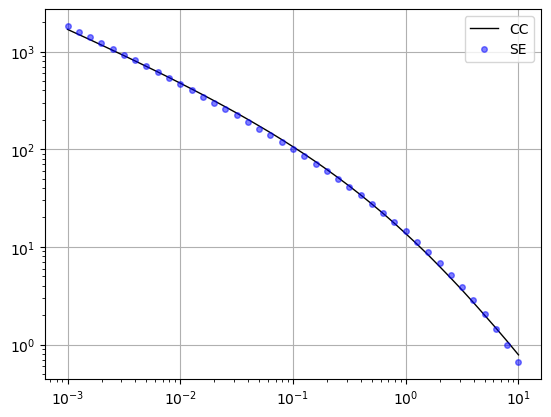

In [56]:
plt.loglog(t*1e3, obsSigma, 'k', lw=1, label='CC')
plt.loglog(t*1e3, predSigma, 'bo', alpha = 0.5, ms=4, label='SE')
plt.grid()
plt.legend()